# 5 &middot; Solving the Minimization: Newton vs. Gradient Descent

Time to open the solver box. We pin a beam's left edge, grab its **whole right
edge** as a handle, fix a target down-and-to-the-right, and drive the beam to
equilibrium from rest with two methods:

* **Gradient descent** &mdash; step along $-\nabla E$.
* **Newton** &mdash; step along $-H^{-1}\nabla E$, using curvature.

Per iteration we track the energy, the gradient norm $\lVert\nabla E\rVert$,
and the **Newton decrement** $\lambda = \sqrt{\nabla E^\top H^{-1}\nabla E}$.

In [1]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import simkit
import utils

## The objective

Elastic + pinned-left-edge + right-edge handle, all stable Neo-Hookean. We keep
the **handle spring soft** (similar magnitude to the elastic forces) so the
problem is not horribly ill-conditioned &mdash; otherwise gradient descent just
yanks the handle and leaves the rest of the beam untouched.

`BeamObjective` is built like every other simulator class: `precompute` runs
once for a **soft beam** (`ym=0.5, pr=0.45`), and it composes the Neo-Hookean
material, a gentle **pin** spring (`K=1e2`), and a soft **handle** spring
(`K=25`). The `energy / gradient / hessian` methods read like the math, summing
their terms **one per line** &mdash; exactly what the solver loop wants.

In [2]:
class BeamObjective:
    """elastic(x) + pinned-left-edge spring + right-edge handle spring."""

    def __init__(self, X, T):
        self.p   = utils.precompute(X, T, ym=0.5, pr=0.45)   # soft beam
        self.psi = utils.make_material("Neo-Hookean")        # elastic term
        self.pin    = utils.PenaltySpring(self.p.n, self.p.dim, K=1e2)   # gentle pin
        self.handle = utils.PenaltySpring(self.p.n, self.p.dim, K=25.0)  # soft handle

    def set_pin(self, idx, targets):    self.pin.set(idx, targets);    return self
    def set_handle(self, idx, targets): self.handle.set(idx, targets); return self

    def energy(self, x):
        E_elastic = self.psi.energy(x, self.p)
        E_pin     = self.pin.energy(x)
        E_handle  = self.handle.energy(x)
        return E_elastic + E_pin + E_handle

    def gradient(self, x):
        g_elastic = self.psi.gradient(x, self.p)
        g_pin     = self.pin.gradient(x)
        g_handle  = self.handle.gradient(x)
        return g_elastic + g_pin + g_handle

    def hessian(self, x):
        H_elastic = self.psi.hessian(x, self.p)
        H_pin     = self.pin.hessian(x)
        H_handle  = self.handle.hessian(x)
        return H_elastic + H_pin + H_handle

Build the objective **once**: pin the left edge, and aim the
right-edge handle down-and-to-the-right. Both solvers minimize this *same*
objective from the *same* rest state &mdash; the only thing that changes is the
search direction.

In [3]:
X, T = utils.triangulated_grid(nx=12, ny=4, width=2.0, height=0.4)
n, dim = X.shape

pin_idx   = np.where(X[:, 0] <= X[:, 0].min() + 1e-6)[0]
right_idx = np.where(X[:, 0] >= X[:, 0].max() - 1e-6)[0]
targets   = X[right_idx] + np.array([0.5, -0.7])     # pull down-and-right

beam = BeamObjective(X, T).set_pin(pin_idx, X[pin_idx]).set_handle(right_idx, targets)

## The two solver loops

They differ only in the **search direction**. `run_solver` is a thin
solver-iteration loop: given a direction rule it records the energy, gradient
norm, and Newton decrement per iteration and returns the deformed states. Both
use a backtracking line search (tutorial 6).

In [4]:
def run_solver(direction, n_iters=60):
    """direction(g, H) -> step. Returns (states, metrics)."""
    x = X.flatten().reshape(-1, 1).copy()
    states, E, G, DEC = [x.reshape(n, dim).copy()], [], [], []
    for _ in range(n_iters):
        g, H = beam.gradient(x), beam.hessian(x)
        dx = direction(g, H)
        dec = float(np.sqrt(max(-(g.T @ dx)[0, 0], 0.0)))     # sqrt(g^T H^-1 g) for Newton
        alpha, _, _ = simkit.backtracking_line_search(beam.energy, x, g, dx)
        x = x + alpha * dx
        E.append(beam.energy(x)); G.append(float(np.linalg.norm(g))); DEC.append(dec)
        states.append(x.reshape(n, dim).copy())
        if np.linalg.norm(alpha * dx) < 1e-9:
            break
    return states, {"energy": E, "grad": G, "decrement": DEC}

newton_dir = lambda g, H: sp.sparse.linalg.spsolve(H.tocsc(), -g).reshape(-1, 1)
gd_dir     = lambda g, H: -g.reshape(-1, 1)

newton_states, newton_metrics = run_solver(newton_dir)
gd_states,     gd_metrics     = run_solver(gd_dir)
print(f"Newton:           {len(newton_metrics['energy'])} iters, final |grad| = {newton_metrics['grad'][-1]:.2e}")
print(f"Gradient Descent: {len(gd_metrics['energy'])} iters, final |grad| = {gd_metrics['grad'][-1]:.2e}")

Newton:           11 iters, final |grad| = 2.57e-11
Gradient Descent: 60 iters, final |grad| = 2.01e-01


## Convergence curves

Newton's quadratic convergence crushes the gradient norm in a handful of steps;
gradient descent crawls on the stiff, ill-conditioned elastic Hessian. (GD never
forms $H$, so it has no Newton decrement.)

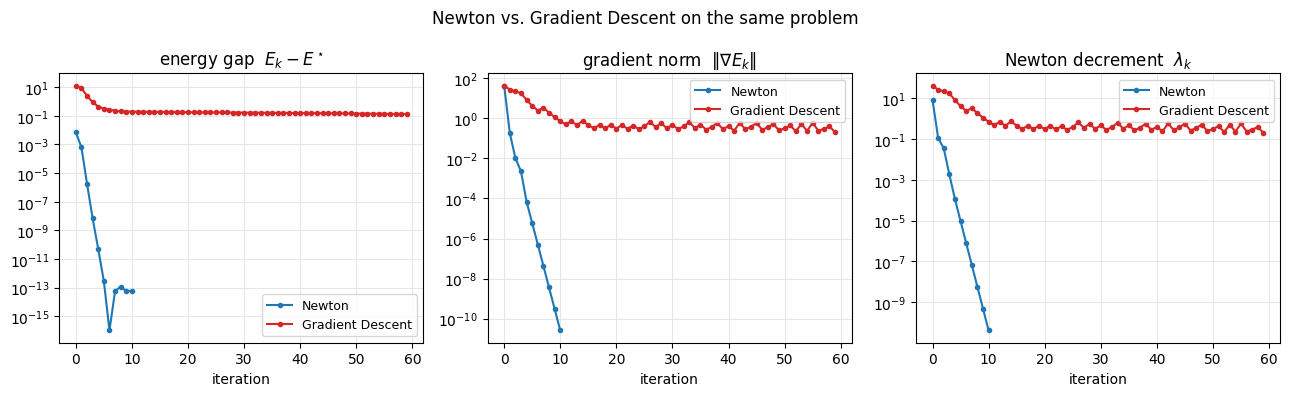

In [5]:
fig, _ = utils.convergence_plot(
    {"Newton": newton_metrics, "Gradient Descent": gd_metrics},
    title="Newton vs. Gradient Descent on the same problem")
plt.show()

## Watching the beam converge (one frame per iteration)

In [6]:
lims = ((-1.2, 1.8), (-1.3, 0.6))
fig, anim = utils.animate_mesh(newton_states, T, lims=lims, title="Newton's method",
    pin_pts=X[pin_idx], handle_traj=[s[right_idx] for s in newton_states],
    target_pts=[targets] * len(newton_states), fps=6)
utils.show_video(fig, anim, "media/05_newton.mp4", fps=6)

In [7]:
fig, anim = utils.animate_mesh(gd_states, T, lims=lims, title="Gradient descent",
    pin_pts=X[pin_idx], handle_traj=[s[right_idx] for s in gd_states],
    target_pts=[targets] * len(gd_states), fps=10)
utils.show_video(fig, anim, "media/05_gradient_descent.mp4", fps=10)

### Takeaways
* **Newton** uses curvature and converges *quadratically* &mdash; ideal for stiff
  elasticity.
* **Gradient descent** ignores curvature and stalls.
* The **Newton decrement** is a clean, scale-aware stopping measure.

But the Newton *step length* needs care &mdash; that's tutorial 6.